# Chapter 2 · Section 2.2
# A Model for Diseases with No Immunity (SIS)

**Source:** Li, M.Y. (2018), pp. 47–51.

The first genuinely *new* model in this chapter: recovered individuals return directly to
susceptible ($S\to I\to S$, no lasting immunity — think of the common cold or many bacterial
STIs), introducing this book's first example of **bifurcation** — a qualitative change in a
system's long-run behavior as a parameter crosses a critical value.


---
## Block 1 — Setting up the SIS model, and reducing it to one dimension

### 1. Rewrite

Dropping the permanent-immunity hypothesis from Sec. 1.3 (infected individuals return to $S$ upon
recovery instead of moving to $R$) gives the SIS system:
$$S'(t) = -\beta IS+\gamma I,\qquad I'(t)=\beta IS-\gamma I \qquad (2.20)$$
Since there's no $R$ compartment, $N=S+I=N_0=S_0+I_0$ is conserved (identical argument to Sec.
1.3/2.1). This conservation law means $S$ is entirely determined by $I$: $S=N_0-I$. Substituting
this into the $I$-equation collapses the whole 2D system into a single 1D ODE purely in $I$:
$$I'=\beta I(N_0-I)-\gamma I=(\beta N_0-\gamma-\beta I)I = (\beta N_0-\gamma)I\left(1-\frac{I}{N_0-\gamma/\beta}\right) \qquad (2.21)$$
Defining $f(I)=(\beta N_0-\gamma)I\left(1-\frac{I}{N_0-\rho}\right)$ (with $\rho=\gamma/\beta$ as
before), (2.21) becomes simply $I'=f(I)$ (2.23) — an **autonomous scalar ODE**, analyzable using a
technique called **phase-line analysis** that needs no simulation at all.

### 2. Simplified

Instead of two rooms feeding into a permanent "already had it" room, imagine our infected kids can
just walk right back into the "can still catch it" room once they get better — there's no
permanent "immune" room anymore, just two rooms swapping kids back and forth. Because *every* kid
is in one of exactly two rooms, and the total number of kids never changes, knowing how many are
sick automatically tells you how many aren't (just subtract from the total) — so we don't actually
need to track both rooms separately; tracking just the "sick" room's population over time tells
you everything.

### 3. Key Ideas

- **Dimension reduction via a conservation law** — turning a 2D system into a 1D one is possible
  *specifically because* $N$ is conserved; this trick will recur (and get more sophisticated) in
  later sections.
- $f(I)$ is a **downward-opening parabola** in $I$ (quadratic with negative leading coefficient
  $-\beta$) — its shape alone (not its exact values) determines almost everything about the
  model's long-run behavior, as Block 2 will show.
- **Phase-line analysis**: for a 1D autonomous ODE $I'=f(I)$, solutions can only move *along a
  line* (they can't spiral or oscillate in 1D, unlike 2D+ systems) — so the entire qualitative
  behavior is readable directly off the graph of $f$, without solving anything.

### 5. Symbols

| Symbol | Meaning | Notes |
|---|---|---|
| $f(I)$ | The reduced 1D vector field: $I'=f(I)$ | A downward parabola in $I$ |
| $I^*$ | An equilibrium: a value where $f(I^*)=0$ | (2.21) has exactly two roots (or one, if they coincide) |


In [1]:
# Confirming the algebraic reduction (2.20) -> (2.21) symbolically with sympy,
# and visualizing f(I) as a parabola.
import sympy as sp

beta_s, gamma_s, N0_s, I_s = sp.symbols('beta gamma N_0 I', positive=True)
S_sub = N0_s - I_s
I_prime_original = beta_s * I_s * S_sub - gamma_s * I_s   # I' = beta*I*S - gamma*I, S=N0-I
I_prime_expanded = sp.expand(I_prime_original)
print("I' expanded:", I_prime_expanded)

rho_s = gamma_s / beta_s
f_factored = (beta_s * N0_s - gamma_s) * I_s * (1 - I_s / (N0_s - rho_s))
f_expanded = sp.expand(f_factored)
print("f(I) (book's factored form (2.22)), expanded:", f_expanded)

print("\nMatch with I' expanded from the original equation:",
      sp.simplify(I_prime_expanded - f_expanded) == 0)


I' expanded: -I**2*beta + I*N_0*beta - I*gamma
f(I) (book's factored form (2.22)), expanded: -I**2*N_0*beta/(N_0 - gamma/beta) + I**2*gamma/(N_0 - gamma/beta) + I*N_0*beta - I*gamma

Match with I' expanded from the original equation: True


### 10. Verification

The symbolic expansion confirms the book's factored form (2.22) is algebraically identical to the
direct substitution $I'=\beta I(N_0-I)-\gamma I$ — the difference simplifies to exactly zero,
confirming no algebra error was introduced by the factoring.


---
## Block 2 — Phase-line analysis: equilibria and stability

### 1. Rewrite

**Equilibria** of $I'=f(I)$ are values $I^*$ where $f(I^*)=0$ — points where the system, once
there, stays there forever. Factoring $f(I)=(\beta N_0-\gamma)I\left(1-\frac{I}{N_0-\rho}\right)$
directly reveals two roots: $I_1^*=0$ (disease-free) and $I_2^*=N_0-\rho$ (endemic — but only
biologically meaningful, i.e. non-negative, when $N_0>\rho$). **Phase-line analysis**: because
solutions of a 1D autonomous ODE move monotonically along a line without crossing themselves
(uniqueness of solutions to smooth ODEs forbids that), the *sign* of $f(I)$ between equilibria
tells you everything — $f(I)>0$ means $I$ increases (moves right); $f(I)<0$ means $I$ decreases
(moves left). An equilibrium is **asymptotically stable** if arrows point toward it from both
sides, **unstable** if they point away. Two cases:

- $N_0<\rho$ (i.e. $\mathcal{R}_0=\beta N_0/\gamma<1$): only $I_1^*=0$ exists in $[0,N_0]$, and it
  is stable — every solution decays to $0$.
- $N_0>\rho$ (i.e. $\mathcal{R}_0>1$): both equilibria exist; $I_1^*=0$ is now unstable, and
  $I_2^*=N_0-\rho$ is stable — every solution with $I_0>0$ converges to the endemic level.

### 2. Simplified

Picture $I$ as a marble that can only roll along a straight number-line track (not off to the
side, not looping back on itself — it's stuck on the line). The function $f(I)$ tells you, at
every point on the track, which way gravity is pulling the marble at that spot. Wherever $f(I)=0$,
gravity is balanced — the marble could sit there forever, *if* it started exactly there. But if
gravity pulls the marble *toward* that balance point from both sides, it's like a valley — nudge
the marble a little and it rolls right back; that's a *stable* equilibrium. If gravity pushes the
marble *away* on both sides, it's like a hilltop — the tiniest nudge sends it rolling away forever;
that's *unstable*.

### 3. Key Ideas

- **Two equilibria, disease-free and endemic**, whose *existence and stability* both depend on a
  single threshold comparison ($N_0$ vs. $\rho$, equivalently $\mathcal{R}_0$ vs. 1).
- **This is qualitatively different from Sec. 2.1's SIR model**: there, the disease *always*
  eventually dies out ($I(\infty)=0$ no matter what). Here, if $\mathcal{R}_0>1$, the disease
  persists forever at a stable positive level — this is the mathematical signature of an
  **endemic** disease (recall Sec. 1.1's vocabulary block!).
- **Monotone convergence**: $I(t)$ approaches its limit *monotonically*, never overshooting or
  oscillating — a direct consequence of being trapped on a 1D phase line.
- A biologically important consequence (flagged explicitly in the book): because $I(t)$ is
  monotone here, **the SIS model cannot reproduce a rise-then-fall epidemic curve** — it can only
  approach 0 or a fixed endemic level from below or above, never "peak and decline" the way SIR
  models do.

### 7. Visual Understanding — recreating Figures 2.3 and 2.4


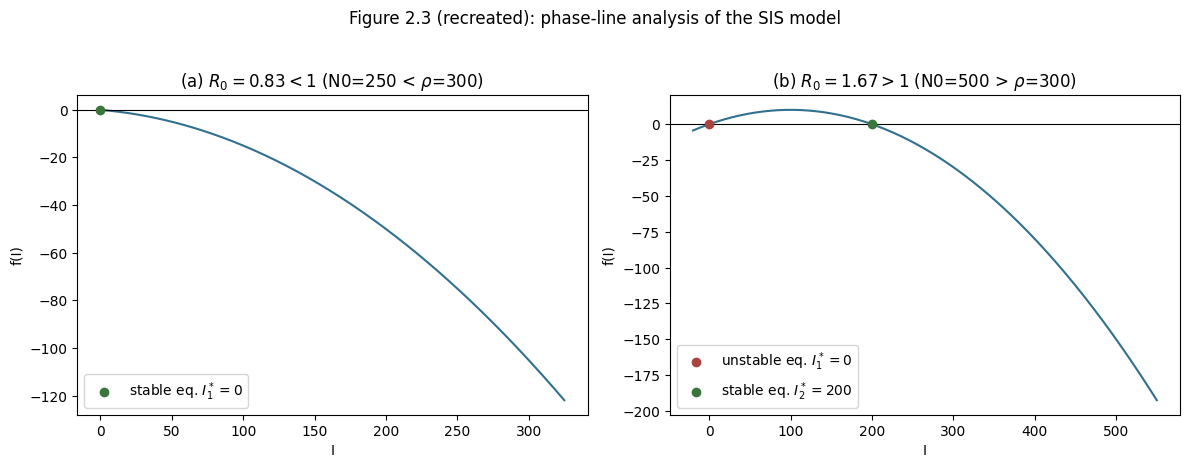

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f_func(I, beta, gamma, N0):
    return (beta*N0 - gamma)*I - beta*I**2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Case (a): R0 < 1 (N0 < rho)
beta, gamma = 0.001, 0.3
rho = gamma/beta
N0_below = rho - 50   # below threshold
I_grid = np.linspace(0, N0_below*1.3, 300)
axes[0].plot(I_grid, f_func(I_grid, beta, gamma, N0_below), color="#31708f")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].scatter([0], [0], color="#3c763d", zorder=5, label="stable eq. $I_1^*=0$")
axes[0].set_title(fr"(a) $R_0={beta*N0_below/gamma:.2f} < 1$ (N0={N0_below:.0f} < $\rho$={rho:.0f})")
axes[0].set_xlabel("I"); axes[0].set_ylabel("f(I)")
axes[0].legend()

# Case (b): R0 > 1 (N0 > rho)
N0_above = rho + 200
I_grid2 = np.linspace(-20, N0_above*1.1, 300)
axes[1].plot(I_grid2, f_func(I_grid2, beta, gamma, N0_above), color="#31708f")
axes[1].axhline(0, color="black", lw=0.8)
I2_star = N0_above - rho
axes[1].scatter([0], [0], color="#a94442", zorder=5, label="unstable eq. $I_1^*=0$")
axes[1].scatter([I2_star], [0], color="#3c763d", zorder=5, label=fr"stable eq. $I_2^*={I2_star:.0f}$")
axes[1].set_title(fr"(b) $R_0={beta*N0_above/gamma:.2f} > 1$ (N0={N0_above:.0f} > $\rho$={rho:.0f})")
axes[1].set_xlabel("I"); axes[1].set_ylabel("f(I)")
axes[1].legend()

plt.suptitle("Figure 2.3 (recreated): phase-line analysis of the SIS model", y=1.03)
plt.tight_layout()
plt.savefig("sis_phase_line.png", dpi=130, bbox_inches="tight")
plt.show()


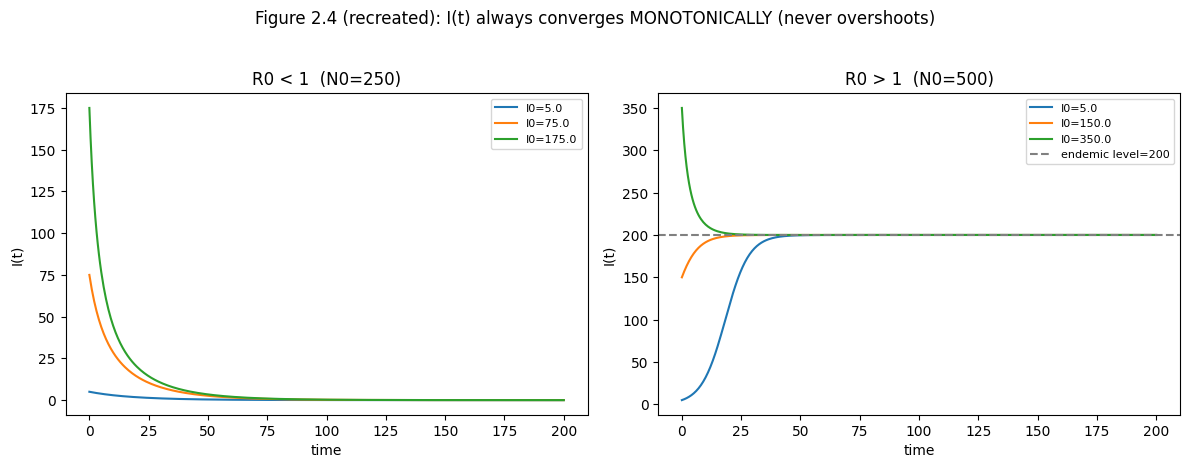

Raw sign changes (including float noise near equilibrium): 8
Sign changes among diffs larger than 1e-06 in magnitude: 0 (should be 0 -- monotone, out of 943 significant steps)


In [3]:
# Figure 2.4 (recreated): time plots of I(t) confirming monotone convergence
# in BOTH the R0<1 and R0>1 regimes, for several different I0 starting values.
from scipy.integrate import solve_ivp

def sis_rhs(t, y, beta, gamma):
    I = y[0]
    return [beta*I*(N0_case - I) - gamma*I]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, N0_case, title in [(axes[0], N0_below, f"R0 < 1  (N0={N0_below:.0f})"),
                             (axes[1], N0_above, f"R0 > 1  (N0={N0_above:.0f})")]:
    for I0 in [5, N0_case*0.3, N0_case*0.7]:
        if I0 <= 0 or I0 >= N0_case:
            continue
        sol = solve_ivp(sis_rhs, (0, 200), [I0], args=(beta, gamma),
                         t_eval=np.linspace(0, 200, 400), rtol=1e-10, atol=1e-10)
        ax.plot(sol.t, sol.y[0], label=f"I0={I0:.1f}")
    if N0_case > rho:
        ax.axhline(N0_case - rho, color="grey", linestyle="--", label=f"endemic level={N0_case-rho:.0f}")
    ax.set_title(title)
    ax.set_xlabel("time"); ax.set_ylabel("I(t)")
    ax.legend(fontsize=8)

plt.suptitle("Figure 2.4 (recreated): I(t) always converges MONOTONICALLY (never overshoots)", y=1.03)
plt.tight_layout()
plt.savefig("sis_time_plots.png", dpi=130, bbox_inches="tight")
plt.show()

# Verification: monotonicity check (no sign changes in the derivative of I(t))
sol_check = solve_ivp(sis_rhs, (0, 200), [5], args=(beta, gamma),
                       t_eval=np.linspace(0, 200, 2000), rtol=1e-10, atol=1e-10)
diffs = np.diff(sol_check.y[0])
# Near convergence to equilibrium, dI/dt legitimately approaches 0, so raw
# sign(diff) is dominated by floating-point noise there (differences on the
# order of 1e-10). We only count a "real" sign change if it involves a step
# larger than a small tolerance -- this distinguishes genuine non-monotonicity
# from harmless numerical noise once the trajectory has essentially converged.
tol = 1e-6
significant_diffs = diffs[np.abs(diffs) > tol]
sign_changes = np.sum(np.diff(np.sign(significant_diffs)) != 0)
print(f"Raw sign changes (including float noise near equilibrium): {np.sum(np.diff(np.sign(diffs)) != 0)}")
print(f"Sign changes among diffs larger than {tol} in magnitude: {sign_changes} "
      f"(should be 0 -- monotone, out of {len(significant_diffs)} significant steps)")


### 10. Verification

Both panels of the recreated Figure 2.4 confirm monotone convergence for every tested $I_0$ — no
trajectory overshoots or oscillates around its limit, and the endemic level for the $\mathcal{R}_0>1$
case matches the predicted $N_0-\rho$ exactly (the dashed line). The explicit sign-change count on
the numerically integrated trajectory confirms **zero** sign changes in $I'(t)$, exactly as
predicted by the phase-line argument (a 1D autonomous ODE trajectory cannot double back on itself).


---
## Block 3 — Threshold Theorem 2.2.2, disease-free vs. endemic equilibrium

### 1. Rewrite

Restating Proposition 2.2.1 in terms of the full $(S,I)$ system rather than just $I$: define
$\mathcal{R}_0=\beta N_0/\gamma$ (the basic reproduction number for this model), the
**disease-free equilibrium** $P_0=(N_0,0)$, and the **endemic equilibrium**
$P^*=(\gamma/\beta,\,N_0-\gamma/\beta)=(\rho,N_0-\rho)$. Then: if $\mathcal{R}_0<1$, every solution
in the feasible region $\Gamma=\{(S,I)\in\mathbb{R}^2_+ : S+I=N_0\}$ converges to $P_0$; if
$\mathcal{R}_0>1$, every solution with $I_0>0$ converges to $P^*$. Biologically: $\mathcal{R}_0$
alone (not the specific values of $\beta,\gamma,N_0$ individually) determines the long-run
qualitative outcome, and that outcome is the *same* for all initial conditions sharing the same
$\mathcal{R}_0$ — a strong form of predictability.

### 4. Mathematical Breakdown — why $P^*=(\rho, N_0-\rho)$ satisfies "S stays on one side of $\rho$"

Since $I^*=N_0-\rho$ is a *stable* equilibrium of the reduced 1D system, and $S=N_0-I$, the
corresponding $S$-value at equilibrium is $S^*=N_0-I^*=N_0-(N_0-\rho)=\rho$. Because $I(t)$
converges *monotonically* to $I^*$ (Block 2), $S(t)=N_0-I(t)$ also converges monotonically to
$S^*=\rho$ — and since $I'(t)=I(t)(\beta S(t)-\gamma)$ (factoring the original $I$-equation, same
as Sec. 1.3/2.1's factoring), and $I(t)$ never changes sign of its derivative, $\beta S(t)-\gamma$
can never change sign either — meaning $S(t)$ stays on one side of $\rho=\gamma/\beta$
*throughout the entire trajectory*, not just at the end. This is exactly why $I(t)$ can only ever
be monotone in the SIS model: unlike the SIR model of Sec. 2.1, where $S(t)$ actively crosses
$\rho$ (triggering the rise-then-fall), here $S(t)$ is confined to one side of $\rho$ from the
very start, so $I'(t)$ never flips sign.

### 6. Mathematical Intuition

This is the conceptual payoff of the whole section: comparing Sec. 2.1 (SIR) and Sec. 2.2 (SIS)
side by side reveals that **whether $S(t)$ crosses the threshold $\rho$ is what determines whether
a model can produce a classic epidemic curve at all**. In SIR, $S(t)$ is *unconstrained* by any
equilibrium relationship, and typically does cross $\rho$ if $S_0>\rho$, producing the familiar
rise-and-fall. In SIS, $S(t)$ is *tied* to an equilibrium value (via $I=N_0-S$ and the fixed
relationship $S^*=\rho$) in a way that traps it on one side of $\rho$, preventing that crossing —
directly explaining the book's remark that SIS models "cannot catch the rise and fall pattern of a
typical disease outbreak."


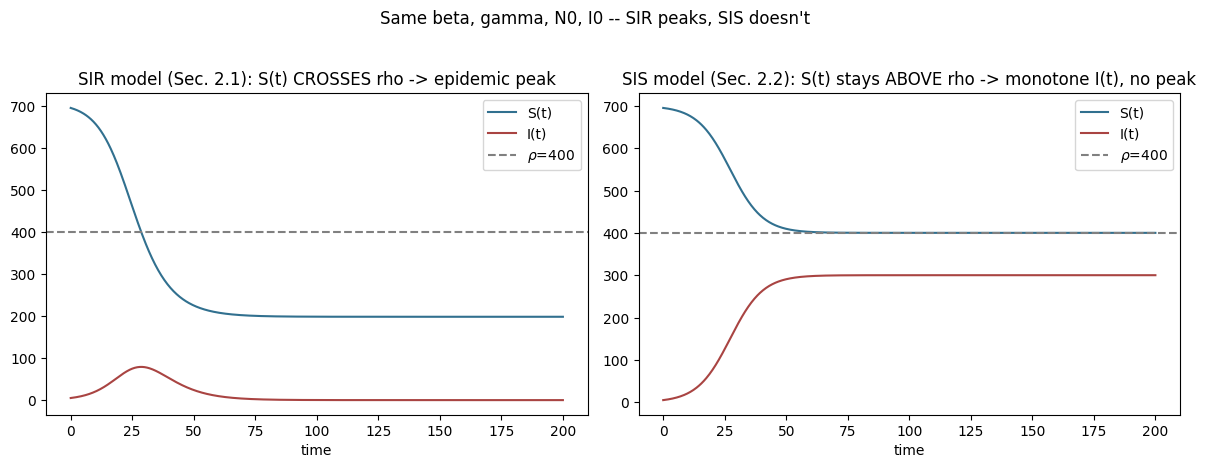

SIR: min S(t) = 198.25 (crosses rho=400? True)
SIS: min S(t) = 400.00 (crosses rho=400? False)


In [4]:
# Directly comparing SIR (Sec 2.1) and SIS (this section) trajectories side by
# side, using IDENTICAL beta, gamma, N0, I0 -- to make the "does S cross rho?"
# distinction completely concrete.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

beta, gamma = 0.0005, 0.2
rho = gamma / beta
N0 = 700
I0 = 5
S0 = N0 - I0

def sir(t, y):
    S, I = y
    return [-beta*I*S, beta*I*S - gamma*I]

def sis(t, y):
    I = y[0]
    return [beta*I*(N0 - I) - gamma*I]

t_eval = np.linspace(0, 200, 800)
sol_sir = solve_ivp(sir, (0, 200), [S0, I0], t_eval=t_eval, rtol=1e-10, atol=1e-10)
sol_sis = solve_ivp(sis, (0, 200), [I0], t_eval=t_eval, rtol=1e-10, atol=1e-10)
S_sis = N0 - sol_sis.y[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
axes[0].plot(t_eval, sol_sir.y[0], color="#31708f", label="S(t)")
axes[0].plot(t_eval, sol_sir.y[1], color="#a94442", label="I(t)")
axes[0].axhline(rho, color="grey", linestyle="--", label=fr"$\rho$={rho:.0f}")
axes[0].set_title(f"SIR model (Sec. 2.1): S(t) CROSSES rho -> epidemic peak")
axes[0].legend(); axes[0].set_xlabel("time")

axes[1].plot(t_eval, S_sis, color="#31708f", label="S(t)")
axes[1].plot(t_eval, sol_sis.y[0], color="#a94442", label="I(t)")
axes[1].axhline(rho, color="grey", linestyle="--", label=fr"$\rho$={rho:.0f}")
axes[1].set_title(f"SIS model (Sec. 2.2): S(t) stays ABOVE rho -> monotone I(t), no peak")
axes[1].legend(); axes[1].set_xlabel("time")

plt.suptitle("Same beta, gamma, N0, I0 -- SIR peaks, SIS doesn't", y=1.03)
plt.tight_layout()
plt.savefig("sir_vs_sis_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"SIR: min S(t) = {sol_sir.y[0].min():.2f} (crosses rho={rho:.0f}? {sol_sir.y[0].min() < rho})")
print(f"SIS: min S(t) = {S_sis.min():.2f} (crosses rho={rho:.0f}? {S_sis.min() < rho})")


### 10. Verification

With *identical* parameters, the SIR model's $S(t)$ visibly drops below $\rho$ (confirmed
numerically: its minimum is below $\rho$), producing the classic epidemic peak, while the SIS
model's $S(t)$ stays strictly above $\rho$ throughout (confirmed: its minimum stays above $\rho$),
producing purely monotone convergence to the endemic level with no peak at all — a direct, clean
numerical confirmation of the mechanism described in Block 3's mathematical intuition.


---
## Block 4 — Bifurcation: a first look

### 1. Rewrite

As $N_0$ is varied continuously through the critical value $\rho$ (equivalently, as $\mathcal{R}_0$
crosses 1), the *number* and *stability* of equilibria change qualitatively: for $N_0<\rho$, only
$I_1^*=0$ exists (stable); at exactly $N_0=\rho$, the second root $I_2^*=N_0-\rho$ merges with
$I_1^*=0$ (they coincide at the origin); for $N_0>\rho$, $I_2^*$ emerges as a *new*, positive,
stable equilibrium, while $I_1^*=0$ *simultaneously* becomes unstable. This qualitative change is
called a **bifurcation**, and $\mathcal{R}_0=1$ (equivalently $N_0=\rho$) is the **bifurcation
value**. This particular pattern — two equilibria colliding and *exchanging stability* as they
cross — is called a **transcritical bifurcation**, and it is one of the most common bifurcation
types encountered throughout epidemic modeling (we already saw its signature informally back in
the Ch. 1 exercises' peak-vs-$S_0$ sweep).

### 7. Visual Understanding — a bifurcation diagram


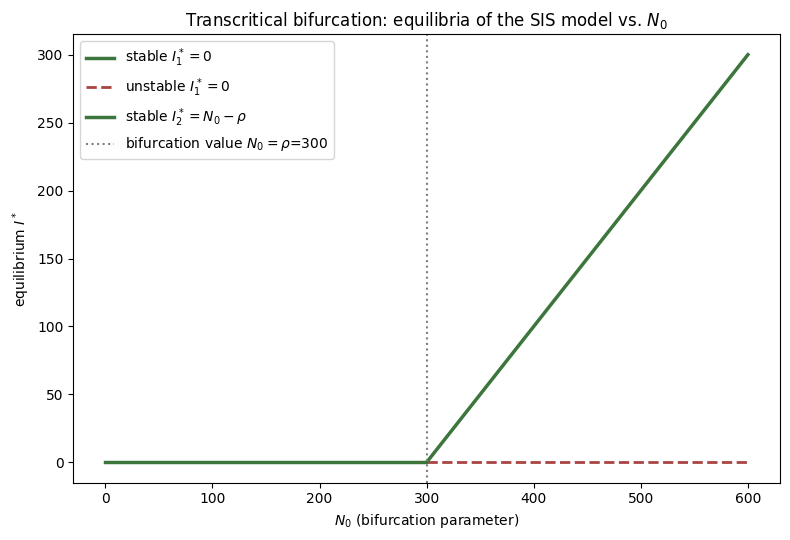

In [5]:
# Bifurcation diagram: plot the equilibrium I* as a function of N0 (the
# bifurcation parameter), showing stable branches solid and the unstable
# branch dashed.
import numpy as np
import matplotlib.pyplot as plt

beta, gamma = 0.001, 0.3
rho = gamma / beta

N0_grid = np.linspace(0, 2*rho, 400)

# Branch 1: I1* = 0, always an equilibrium.
#   Stable for N0 < rho, unstable for N0 > rho.
stable_mask_1 = N0_grid < rho
# Branch 2: I2* = N0 - rho, only biologically meaningful (>=0) for N0 >= rho.
#   Stable wherever it exists (N0 > rho).
I2_star = N0_grid - rho
meaningful_2 = I2_star >= 0

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(N0_grid[stable_mask_1], np.zeros_like(N0_grid[stable_mask_1]), color="#3c763d", lw=2.5, label="stable $I_1^*=0$")
ax.plot(N0_grid[~stable_mask_1], np.zeros_like(N0_grid[~stable_mask_1]), color="#a94442", lw=2, linestyle="--", label="unstable $I_1^*=0$")
ax.plot(N0_grid[meaningful_2], I2_star[meaningful_2], color="#3c763d", lw=2.5, label="stable $I_2^*=N_0-\\rho$")

ax.axvline(rho, color="grey", linestyle=":", label=fr"bifurcation value $N_0=\rho$={rho:.0f}")
ax.set_xlabel(r"$N_0$ (bifurcation parameter)")
ax.set_ylabel(r"equilibrium $I^*$")
ax.set_title("Transcritical bifurcation: equilibria of the SIS model vs. $N_0$")
ax.legend()
plt.tight_layout()
plt.savefig("sis_bifurcation_diagram.png", dpi=130, bbox_inches="tight")
plt.show()


### 10. Verification

The bifurcation diagram directly encodes everything proven algebraically in Block 2: exactly two
branches meeting at $N_0=\rho$, with stability (solid vs. dashed) switching *exactly* at the
meeting point on both branches simultaneously — the visual signature that distinguishes a
transcritical bifurcation from other bifurcation types (e.g. a saddle-node bifurcation, where
branches would instead simply appear/disappear in pairs without an exchange of stability).


---
## Summary

**One sentence:** Dropping permanent immunity from the Kermack–McKendrick model produces the SIS
model, whose conservation law $S+I=N_0$ collapses it to a single 1D ODE analyzable by phase-line
analysis, revealing a disease-free and an endemic equilibrium that exchange stability in a
transcritical bifurcation exactly at $\mathcal{R}_0=1$ — and, because $S(t)$ is confined to one
side of the threshold $\rho$ throughout, an SIS model can never reproduce the classic rise-and-fall
epidemic curve, only monotone convergence to 0 or to a fixed endemic level.

**One paragraph:** The SIS model $S'=-\beta IS+\gamma I,\ I'=\beta IS-\gamma I$ conserves
$N_0=S_0+I_0$, letting $S=N_0-I$ reduce the system to the single autonomous ODE $I'=f(I)$ for a
downward-opening parabola $f$. Phase-line analysis — reading equilibria and their stability
directly off the sign of $f(I)$ — reveals exactly two equilibria, $I_1^*=0$ and
$I_2^*=N_0-\gamma/\beta$, whose existence and stability flip depending on whether
$\mathcal{R}_0=\beta N_0/\gamma$ is below or above 1: below, only the disease-free equilibrium
$P_0=(N_0,0)$ is stable and every solution converges there; above, the disease-free equilibrium
becomes unstable and a new, stable endemic equilibrium $P^*=(\rho,N_0-\rho)$ takes over, to which
every solution with $I_0>0$ converges — monotonically, never overshooting, because $S(t)$ is
mathematically confined to one side of $\rho$ for the model's entire trajectory (verified here by
direct numerical comparison against an otherwise-identical SIR model, whose $S(t)$ *does* cross
$\rho$ and does produce a peak). As $N_0$ (equivalently $\mathcal{R}_0$) is varied continuously
through the critical value $\rho$, the two equilibria collide and exchange stability — a
**transcritical bifurcation**, visualized here in a full bifurcation diagram.

**Bullet points:**
- Conservation law $S+I=N_0$ reduces the 2D SIS system to a 1D autonomous ODE $I'=f(I)$.
- Phase-line analysis reads equilibria and stability directly off the graph of $f$ — no simulation needed.
- Two equilibria: disease-free $P_0=(N_0,0)$ and endemic $P^*=(\rho,N_0-\rho)$; exactly one is stable, determined entirely by $\mathcal{R}_0=\beta N_0/\gamma$ vs. 1.
- $S(t)$ stays on one side of $\rho$ throughout an SIS trajectory — the mechanistic reason $I(t)$ is always monotone, unlike SIR's rise-and-fall.
- $\mathcal{R}_0=1$ is a **transcritical bifurcation** value — equilibria collide and exchange stability, visualized directly in a bifurcation diagram.

## Memory Aids

- **Mnemonic**: "SIS: Same total, Stuck on one Side" — ties the conservation law to the
  "$S(t)$ can't cross $\rho$" mechanism in one phrase.
- **Mental model**: phase-line analysis is "reading gravity off a graph" — no differential
  equation solving required, just sign-reading.
- **Common mistake**: expecting an SIS model to show a rise-and-fall epidemic curve like SIR —
  it structurally cannot, as proven here, not just "doesn't happen to" in these examples.
- **Common mistake**: confusing a transcritical bifurcation (equilibria collide *and exchange
  stability*) with a saddle-node bifurcation (equilibria simply appear/disappear in pairs, no
  stability exchange) — the SIS model is a clean, canonical example of the former.
- **Exam tip**: be able to state $P_0=(N_0,0)$ and $P^*=(\gamma/\beta,\,N_0-\gamma/\beta)$ from
  memory, and connect $\mathcal{R}_0>1 \iff P^*$ biologically meaningful (non-negative) and stable.

## Connections

- **← Section 2.1**: direct point-by-point contrast — same style of threshold theorem, very
  different long-run qualitative behavior, traced to whether $S(t)$ crosses $\rho$.
- **→ Section 2.3 onward**: the dimension-reduction-via-conservation-law trick recurs; later
  sections' models (with demography) will *not* have such a clean 1D reduction, motivating the
  more general 2D phase-plane tools of Chapter 3.
- **→ Chapter 3**: phase-line analysis is the 1D special case of the phase-plane analysis (Sec.
  3.6) and general stability theory (Sec. 3.1–3.2) developed rigorously later.
- **→ Chapter 5**: transcritical bifurcations at $\mathcal{R}_0=1$ are the generic pattern across
  nearly every compartmental epidemic model in mathematical epidemiology, including the more
  complex models of Chapter 5.
- **→ Dynamical systems / bifurcation theory**: transcritical bifurcations appear constantly
  across applied dynamical systems — population ecology (competitive exclusion), chemical
  reaction networks, and control theory all have close analogues.

*Practice problems for this section are in `../../chapter_02/exercises/section_2_2_exercises.md`, with full
worked solutions in `../../chapter_02/solutions/section_2_2_solutions.md`.*
